# Setup and Dependencies


In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install timm efficientnet-pytorch
!pip install kaggle pandas scikit-learn opencv-python tqdm seaborn
!pip install torchmetrics
!pip install pydicom
!pip install --upgrade kaggle

import sys
print("✓ Dependencies installed!")
print(f"Python version: {sys.version}")

import torch
print(f"PyTorch version: {torch.__version__}")
# Use torch.version.cuda to get the CUDA toolkit version
print(f"CUDA toolkit version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Looking in indexes: https://download.pytorch.org/whl/cu118
  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=1dc45bfc4e8c43bf234f3a4a9994c934e21414b8b17f33b53d2384c812f5de1b
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet-pytorch
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 99.1 MB/s eta 0:00:00
✓ Dependencies installed!
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cu128
CUDA toolkit version: 12.8
GPU: NVIDIA L4


# Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Create directory for saving models
import os
os.makedirs('/content/drive/MyDrive/EyeShield/checkpoints', exist_ok=True)
os.makedirs('/content/drive/MyDrive/EyeShield/logs', exist_ok=True)

print("✓ Google Drive mounted!")
print("Save location: /content/drive/MyDrive/EyeShield/")

Mounted at /content/drive
✓ Google Drive mounted!
Save location: /content/drive/MyDrive/EyeShield/


# Setup Kaggle API

In [3]:
from google.colab import files
import json
from pathlib import Path

print("Upload your kaggle.json file...")
print("Instructions:")
print("1. Go to: https://www.kaggle.com/settings/account")
print("2. Click 'Create New API Token'")
print("3. Upload the downloaded kaggle.json file")

uploaded = files.upload()

if 'kaggle.json' in uploaded:
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(exist_ok=True)

    with open(kaggle_dir / 'kaggle.json', 'w') as f:
        f.write(uploaded['kaggle.json'].decode())

    os.chmod(kaggle_dir / 'kaggle.json', 0o600)
    print("✓ Kaggle API configured!")
else:
    print("⚠ kaggle.json not found. You can continue with sample data.")

Upload your kaggle.json file...
Instructions:
1. Go to: https://www.kaggle.com/settings/account
2. Click 'Create New API Token'
3. Upload the downloaded kaggle.json file


Saving kaggle.json to kaggle.json
✓ Kaggle API configured!


# Download Dataset from Kaggle

In [4]:
import kagglehub
import os

# Download the DeepDRiD dataset from Kaggle
dataset_path = kagglehub.dataset_download("nancyhisham/deepdrid")

# Navigate to the regular_fundus_images subfolder
regular_fundus_root = os.path.join(dataset_path, 'regular_fundus_images')

# Confirm the expected subfolders exist
expected = ['regular-fundus-training', 'regular-fundus-validation', 'Online-Challenge1&2-Evaluation']
for folder in expected:
    path = os.path.join(regular_fundus_root, folder)
    status = '✓' if os.path.isdir(path) else '✗ MISSING'
    print(f"{status}  {folder}")

print(f"\n✓ Dataset downloaded to: {dataset_path}")
print(f"  regular_fundus_images root: {regular_fundus_root}")


Using Colab cache for faster access to the 'deepdrid' dataset.
✓  regular-fundus-training
✓  regular-fundus-validation
✓  Online-Challenge1&2-Evaluation

✓ Dataset downloaded to: /kaggle/input/deepdrid
  regular_fundus_images root: /kaggle/input/deepdrid/regular_fundus_images


# Copy Training Script

In [20]:
import os
from urllib.request import urlretrieve

base_url = "https://raw.githubusercontent.com/dondondon22/EyeShield/refs/heads/main"
required_files = [
    "eyeshield_training_preprocessor_deepdrid.py",
    "image_processor.py",
]

print("Downloading required training files...")

for filename in required_files:
    url = f"{base_url}/{filename}"
    destination = f"/content/{filename}"

    try:
        urlretrieve(url, destination)
    except Exception as e:
        raise RuntimeError(
            f"❌ Failed to download {filename} from GitHub.\n"
            f"   URL: {url}\n"
            f"   Error: {e}"
        )

    if not os.path.exists(destination) or os.path.getsize(destination) == 0:
        raise FileNotFoundError(
            f"❌ Downloaded file is missing or empty: {destination}\n"
            f"   Check your internet connection or GitHub URL."
        )

    print(f"✓ Downloaded {filename} ({os.path.getsize(destination) / 1024:.1f} KB)")

print("\n✓ All training dependencies downloaded successfully!")

✓ Downloaded eyeshield_training_preprocessor_deepdrid.py (56.0 KB)
✓ Downloaded image_processor.py (15.5 KB)

✓ All training dependencies downloaded successfully!


# Prepare Dataset CSV

In [6]:
import pandas as pd
import os
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
import kagglehub
dataset_path        = kagglehub.dataset_download('nancyhisham/deepdrid')
regular_fundus_root = os.path.join(dataset_path, 'regular_fundus_images')

TRAIN_DIR = os.path.join(regular_fundus_root, 'regular-fundus-training')
VAL_DIR   = os.path.join(regular_fundus_root, 'regular-fundus-validation')
EVAL_DIR  = os.path.join(regular_fundus_root, 'Online-Challenge1&2-Evaluation')

TRAIN_CSV  = os.path.join(TRAIN_DIR, 'regular-fundus-training.csv')
VAL_CSV    = os.path.join(VAL_DIR,   'regular-fundus-validation.csv')
EVAL_XLSX  = os.path.join(EVAL_DIR,  'Challenge1_labels.xlsx')   # added July 27th

TRAIN_IMG_DIR = os.path.join(TRAIN_DIR, 'Images')
VAL_IMG_DIR   = os.path.join(VAL_DIR,   'Images')
EVAL_IMG_DIR  = os.path.join(EVAL_DIR,  'Images')

os.makedirs('/content/dataset', exist_ok=True)

# ── Helpers ───────────────────────────────────────────────────────────────────
def build_image_path(image_id, img_dir):
    """
    DeepDRiD images live at Images/<patient_id>/<image_id>.jpg
    e.g. image_id '1_l_1' → Images/1/1_l_1.jpg
    """
    patient_id = str(image_id).split('_')[0]
    return os.path.join(img_dir, patient_id, f"{image_id}.jpg")


def get_label_col(df):
    for c in ['patient_DR_Level', 'DR_level', 'label', 'DR_Level', 'DR_Levels']:
        if c in df.columns:
            return c
    raise KeyError(f"Cannot find DR label column. Available: {list(df.columns)}")


def get_id_col(df):
    for c in ['image_id', 'image_name', 'id']:
        if c in df.columns:
            return c
    return df.columns[0]


def build_df(df_raw, img_dir, id_col, label_col, split_name):
    rows, missing = [], 0
    for _, row in df_raw.iterrows():
        image_id  = str(row[id_col])
        diagnosis = int(row[label_col])
        img_path  = build_image_path(image_id, img_dir)
        if not os.path.exists(img_path):
            missing += 1
            continue
        rows.append({'image_path': img_path, 'diagnosis': diagnosis, 'split': split_name})
    if missing:
        print(f"  ⚠ {split_name}: {missing} images not found on disk (skipped)")
    return pd.DataFrame(rows)


# ── Training set (Set-A) ──────────────────────────────────────────────────────
df_train_raw = pd.read_csv(TRAIN_CSV)
print(f'Training CSV columns:   {list(df_train_raw.columns)}')
df_train = build_df(df_train_raw, TRAIN_IMG_DIR,
                    get_id_col(df_train_raw), get_label_col(df_train_raw), 'train')

# ── Validation set (Set-B) ────────────────────────────────────────────────────
df_val_raw = pd.read_csv(VAL_CSV)
print(f'Validation CSV columns: {list(df_val_raw.columns)}')
df_val = build_df(df_val_raw, VAL_IMG_DIR,
                  get_id_col(df_val_raw), get_label_col(df_val_raw), 'val')

# ── Evaluation / test set (Set-C) ─────────────────────────────────────────────
# Labels were released on July 27th and live in Challenge1_labels.xlsx.
# The xlsx has the same image_id + patient_DR_Level columns as the training CSV.
if os.path.exists(EVAL_XLSX):
    df_eval_raw = pd.read_excel(EVAL_XLSX, engine='openpyxl')
    print(f'Evaluation XLSX columns: {list(df_eval_raw.columns)}')
    df_test = build_df(df_eval_raw, EVAL_IMG_DIR,
                       get_id_col(df_eval_raw), get_label_col(df_eval_raw), 'test')
else:
    # Fallback: try Challenge1_upload.csv which lists image IDs without labels.
    # In this case we cannot use the evaluation set for testing.
    print(f"⚠ Challenge1_labels.xlsx not found at: {EVAL_XLSX}")
    print("  The July 27th label release may not be present in this Kaggle mirror.")
    print("  Test set will be empty — consider using a held-out slice of Set-B instead.")
    df_test = pd.DataFrame(columns=['image_path', 'diagnosis', 'split'])

# ── Combine and save ──────────────────────────────────────────────────────────
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

out_csv = '/content/dataset/labels.csv'
df_all.to_csv(out_csv, index=False)

with open('/content/dataset/data_root.txt', 'w') as f:
    f.write(regular_fundus_root)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n✓ labels.csv saved → {out_csv}")
print(f"  Train (Set-A):      {len(df_train):>4d} images")
print(f"  Val   (Set-B):      {len(df_val):>4d} images")
print(f"  Test  (Set-C eval): {len(df_test):>4d} images")
print(f"  Total:              {len(df_all):>4d} images")
print(f"\nClass distribution (diagnosis 0–4):")
print(df_all.groupby(['split', 'diagnosis']).size().unstack(fill_value=0))
print(f"\nSample rows:")
print(df_all.groupby('split').head(1)[['split','image_path','diagnosis']].to_string(index=False))

Using Colab cache for faster access to the 'deepdrid' dataset.
Training CSV columns:   ['patient_id', 'image_id', 'image_path', 'Overall quality', 'left_eye_DR_Level', 'right_eye_DR_Level', 'patient_DR_Level', 'Clarity', 'Field definition', 'Artifact']
Validation CSV columns: ['patient_id', 'image_id', 'image_path', 'Overall quality', 'left_eye_DR_Level', 'right_eye_DR_Level', 'patient_DR_Level', 'Clarity', 'Field definition', 'Artifact']
Evaluation XLSX columns: ['image_id', 'DR_Levels']

✓ labels.csv saved → /content/dataset/labels.csv
  Train (Set-A):      1200 images
  Val   (Set-B):       400 images
  Test  (Set-C eval):  400 images
  Total:              2000 images

Class distribution (diagnosis 0–4):
diagnosis    0    1    2    3    4
split                             
test       200   36   72   72   20
train      360  240  240  240  120
val        120   80   80   80   40

Sample rows:
split                                                                                        i

# Preprocess and Cache Images (One-Time Setup)

This step preprocesses all images at once and caches them to disk. Subsequent training runs load from cache (10x faster).
Run this cell ONCE before training. Takes ~30-60 minutes depending on dataset size.

In [7]:
# Cache will be saved to Colab ephemeral storage (/content/image_cache)
# This does NOT use Google Drive storage
# Note: Cache is cleared when session ends (run preprocessing again next session)

CACHE_DIR = '/content/image_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"✓ Cache location: {CACHE_DIR}")
print(f"  Storage: Colab ephemeral (doesn't use Google Drive)")
print(f"  Available: ~80+ GB during session")
print(f"  Persists: Until session ends")
print(f"\nFirst session: Preprocess once (~1-2 hours)")
print(f"Same session: Lightning fast afterward!")

✓ Cache location: /content/image_cache
  Storage: Colab ephemeral (doesn't use Google Drive)
  Available: ~80+ GB during session
  Persists: Until session ends

First session: Preprocess once (~1-2 hours)
Same session: Lightning fast afterward!


In [8]:
import os
import numpy as np
import pickle
from pathlib import Path
from tqdm import tqdm
import shutil
import cv2
import pydicom
import pandas as pd
from sklearn.model_selection import train_test_split

# ==================== IMAGE PREPROCESSOR ====================
class ImagePreprocessor:
    """Image preprocessing for fundus images"""

    def __init__(self, target_size=(512, 512)):
        """
        Initialize preprocessor

        Args:
            target_size: Target image size (height, width)
        """
        self.target_size = target_size

    def preprocess_fundus_image(self, image_path):
        """
        Preprocesses a fundus image by resizing it to the target size.
        Supports DICOM (.dcm) and standard image formats (jpg, png, etc.)
        """
        file_ext = os.path.splitext(image_path)[1].lower()

        if file_ext == '.dcm':
            try:
                dicom = pydicom.dcmread(image_path)
                img = dicom.pixel_array

                if img.dtype != np.uint8:
                    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

                if len(img.shape) == 2:
                    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

            except Exception as e:
                raise ValueError(f"Error reading DICOM file: {str(e)}")
        else:
            img = cv2.imread(image_path)
            if img is None:
                raise ValueError(f"Image not found or invalid path: {image_path}")

        img_resized = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LANCZOS4)
        img_normalized = img_resized.astype(np.float32) / 255.0

        return img_normalized

    def assess_image_quality(self, preprocessed_img, blur_threshold=70,
                            brightness_low=30, brightness_high=220, entropy_high=7.5):
        """Assesses the quality of a preprocessed fundus image"""
        img_uint8 = (preprocessed_img * 255).astype(np.uint8)

        if len(img_uint8.shape) == 3 and img_uint8.shape[2] == 3:
            gray = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
        else:
            gray = img_uint8 if len(img_uint8.shape) == 2 else cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        mean_brightness = np.mean(gray)
        hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
        hist_norm = hist / hist.sum()
        entropy = -np.sum(hist_norm * np.log2(hist_norm + 1e-10))

        quality_info = {
            'blur_var': float(laplacian_var),
            'brightness': float(mean_brightness),
            'entropy': float(entropy),
            'blur_threshold': blur_threshold,
            'brightness_low': brightness_low,
            'brightness_high': brightness_high,
            'entropy_threshold': entropy_high
        }

        if laplacian_var < blur_threshold:
            quality_result = "Rejected: Blurry or out of focus"
            quality_score = 0.3
        elif mean_brightness < brightness_low:
            quality_result = "Rejected: Too dark"
            quality_score = 0.2
        elif mean_brightness > brightness_high:
            quality_result = "Rejected: Too bright"
            quality_score = 0.2
        elif entropy > entropy_high:
            quality_result = "Rejected: Artifacts or obstructions"
            quality_score = 0.4
        else:
            quality_result = "Gradable"
            quality_score = 0.9

        return quality_score, quality_result, quality_info

    def preprocess(self, image_path, assess_quality=True):
        """Complete preprocessing pipeline"""
        try:
            image = self.preprocess_fundus_image(image_path)

            if assess_quality:
                quality_score, quality_result, quality_info = self.assess_image_quality(image)
            else:
                quality_score = 1.0
                quality_result = "Not assessed"
                quality_info = {}

            return image, quality_score, quality_info
        except Exception as e:
            print(f"Error preprocessing {image_path}: {e}")
            return None, 0.0, {}


# ==================== IMAGE CACHE MANAGER ====================
class ImageCacheManager:
    """Manage image preprocessing and caching"""

    def __init__(self, cache_dir='/content/image_cache', preprocessor=None):
        self.cache_dir = cache_dir
        self.preprocessor = preprocessor
        os.makedirs(cache_dir, exist_ok=True)
        self.metadata_file = os.path.join(cache_dir, 'metadata.pkl')

    def get_cache_path(self, image_filename):
        """Get cache file path for an image"""
        # Remove any path separators and create safe filename
        safe_filename = image_filename.replace('/', '__').replace('\\', '__')
        return os.path.join(self.cache_dir, f"{safe_filename}.npy")

    def preprocess_and_cache(self, df, dataset_root, force_reprocess=False):
        """
        Preprocess all images and cache them as uint8 (4x smaller than float32).
        Images are stored in [0, 255] uint8 and converted back to [0.0, 1.0] float32 on load.

        Args:
            df: DataFrame with 'image_path' column
            dataset_root: Root directory containing images
            force_reprocess: If True, reprocess even if cached
        """
        print(f"Preprocessing {len(df)} images to cache...")
        print(f"Cache location: {self.cache_dir}")
        print(f"Dataset root: {dataset_root}")
        print(f"Storage format: uint8 (4x smaller than float32)\n")

        cached_count = 0
        new_count = 0
        failed_images = []

        cache_metadata = {}

        pbar = tqdm(total=len(df), desc='Caching images')

        for idx, row in df.iterrows():
            img_path = os.path.join(dataset_root, row['image_path'])
            cache_path = self.get_cache_path(row['image_path'])

            if os.path.exists(cache_path) and not force_reprocess:
                cached_count += 1
                cache_metadata[row['image_path']] = 'cached'
                pbar.update(1)
                continue

            try:
                preprocessed_img, quality_score, quality_info = self.preprocessor.preprocess(
                    img_path, assess_quality=False
                )

                if preprocessed_img is None:
                    failed_images.append((row['image_path'], 'Preprocessing returned None'))
                    pbar.update(1)
                    continue

                # Save as uint8 [0, 255] — 4x smaller than float32 [0.0, 1.0]
                # load_cached_image converts back to float32 on load
                np.save(cache_path, (preprocessed_img * 255).astype(np.uint8))
                new_count += 1
                cache_metadata[row['image_path']] = 'new'

            except Exception as e:
                failed_images.append((row['image_path'], str(e)))
                cache_metadata[row['image_path']] = 'failed'

            pbar.update(1)

        pbar.close()

        with open(self.metadata_file, 'wb') as f:
            pickle.dump(cache_metadata, f)

        print(f"\n{'='*80}")
        print(f"CACHING COMPLETE")
        print(f"{'='*80}")
        print(f"Total images: {len(df)}")
        print(f"  ✓ Already cached: {cached_count}")
        print(f"  ✓ Newly cached: {new_count}")
        print(f"  ✗ Failed: {len(failed_images)}")
        print(f"\nCache size: {self._get_cache_size_gb():.2f} GB")
        print(f"{'='*80}\n")

        if failed_images:
            print("Failed images:")
            for img_path, error in failed_images[:10]:
                print(f"  - {img_path}: {error}")
            if len(failed_images) > 10:
                print(f"  ... and {len(failed_images) - 10} more")

        return len(failed_images) == 0

    def load_cached_image(self, image_filename):
        """Load preprocessed image from cache, converting uint8 back to float32"""
        cache_path = self.get_cache_path(image_filename)
        if not os.path.exists(cache_path):
            raise FileNotFoundError(f"Cached image not found: {cache_path}")
        img = np.load(cache_path)
        # Convert uint8 [0, 255] back to float32 [0.0, 1.0]
        if img.dtype == np.uint8:
            return img.astype(np.float32) / 255.0
        return img.astype(np.float32)

    def clear_cache(self):
        """Clear all cached images"""
        if os.path.exists(self.cache_dir):
            shutil.rmtree(self.cache_dir)
            os.makedirs(self.cache_dir)
            print(f"✓ Cache cleared: {self.cache_dir}")

    def _get_cache_size_gb(self):
        """Get total cache size in GB"""
        total_size = 0
        for file in os.listdir(self.cache_dir):
            file_path = os.path.join(self.cache_dir, file)
            if os.path.isfile(file_path):
                total_size += os.path.getsize(file_path)
        return total_size / (1024**3)


# STEP 1: Clear old cache if it exists (to remove files with incorrect paths)
print("⏳ Clearing old cache with incorrect paths...")
cache_dir = '/content/image_cache'
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("✓ Old cache cleared")
os.makedirs(cache_dir, exist_ok=True)

# Initialize image preprocessor
print("✓ Initializing ImagePreprocessor...")
preprocessor = ImagePreprocessor(target_size=(512, 512))
print(f"  - Target size: (512, 512)")

# Initialize cache manager with preprocessor
print("✓ Initializing ImageCacheManager...")
cache_manager = ImageCacheManager(
    cache_dir='/content/image_cache',
    preprocessor=preprocessor
)
print(f"  - Cache directory: /content/image_cache")

# Load the dataset CSV and cache all images
print("\n⏳ Loading dataset from CSV...")
csv_path = '/content/dataset/labels.csv'
df = pd.read_csv(csv_path)
print(f"✓ Loaded {len(df)} images from {csv_path}")

# Load the data root that was saved during CSV creation
data_root_file = '/content/dataset/data_root.txt'
if os.path.exists(data_root_file):
    with open(data_root_file, 'r') as f:
        dataset_root = f.read().strip()
    print(f"✓ Using saved data root: {dataset_root}")
else:
    # Fallback if data_root.txt doesn't exist
    import kagglehub
    dataset_root = kagglehub.dataset_download("ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy")
    print(f"⚠ data_root.txt not found, using fresh download: {dataset_root}")

# Verify the actual data paths will be found
print("\n⏳ Verifying image paths...")
sample_path = os.path.join(dataset_root, df.iloc[0]['image_path'])
if os.path.exists(sample_path):
    print(f"✓ Sample image found: {sample_path}")
else:
    print(f"✗ Warning: Sample image not found at {sample_path}")
    print(f"  CSV image_path: {df.iloc[0]['image_path']}")
    print(f"  Data root: {dataset_root}")
    print(f"  Tried path: {sample_path}")
    # Show what's actually in the directory
    print(f"  Contents of data root: {os.listdir(dataset_root)[:5]}")

# Prepare all images for caching
print("\n⏳ Starting image caching operation...")
print("This is a one-time operation; subsequent runs will skip already-cached images\n")
cache_manager.preprocess_and_cache(df, dataset_root, force_reprocess=False)

print("✓ Images cached! Training will now load from cache (10x faster).")
print("  To recache (if you change preprocessing), call:")
print("  cache_manager.preprocess_and_cache(df, dataset_root, force_reprocess=True)")


⏳ Clearing old cache with incorrect paths...
✓ Old cache cleared
✓ Initializing ImagePreprocessor...
  - Target size: (512, 512)
✓ Initializing ImageCacheManager...
  - Cache directory: /content/image_cache

⏳ Loading dataset from CSV...
✓ Loaded 2000 images from /content/dataset/labels.csv
✓ Using saved data root: /kaggle/input/deepdrid/regular_fundus_images

⏳ Verifying image paths...
✓ Sample image found: /kaggle/input/deepdrid/regular_fundus_images/regular-fundus-training/Images/1/1_l1.jpg

⏳ Starting image caching operation...
This is a one-time operation; subsequent runs will skip already-cached images

Preprocessing 2000 images to cache...
Cache location: /content/image_cache
Dataset root: /kaggle/input/deepdrid/regular_fundus_images
Storage format: uint8 (4x smaller than float32)



Caching images: 100%|██████████| 2000/2000 [01:05<00:00, 30.72it/s]


CACHING COMPLETE
Total images: 2000
  ✓ Already cached: 0
  ✓ Newly cached: 2000
  ✗ Failed: 0

Cache size: 1.47 GB

✓ Images cached! Training will now load from cache (10x faster).
  To recache (if you change preprocessing), call:
  cache_manager.preprocess_and_cache(df, dataset_root, force_reprocess=True)


# Important: Cache is Ephemeral in Colab

⚠️ **Important:** The cache will be cleared when your Colab session ends.

**Workflow:**
- First run in session: Preprocess all images (~30-60 min) → stored in `/content/image_cache`
- Train immediately after: Use cached images (6 min/epoch) ✓
- Next Colab session: Must preprocess again (cache was deleted)

**To minimize re-preprocessing:**
- Keep the same session running during all your training epochs
- Don't restart the kernel
- If session times out, just run preprocessing again

# Modify Config and Run Training

In [21]:
# Read the training script
with open('/content/eyeshield_training_preprocessor_deepdrid.py', 'r') as f:
    training_code = f.read()

# Modify paths in the Config class (if needed)
modified_code = training_code.replace(
    "CHECKPOINT_DIR = './checkpoints'",
    "CHECKPOINT_DIR = '/content/drive/MyDrive/EyeShield/checkpoints'"
)

modified_code = modified_code.replace(
    "LOG_DIR = './logs'",
    "LOG_DIR = '/content/drive/MyDrive/EyeShield/logs'"
)

# Save modified script
with open('/content/eyeshield_training_preprocessor_deepdrid_modified.py', 'w') as f:
    f.write(modified_code)

print("✓ Configuration updated!")
print("Ready to start training...")

✓ Configuration updated!
Ready to start training...


# Backup

In [10]:

# Setup Auto-Backup on Colab Interruption
import shutil
import signal
import atexit
from datetime import datetime as dt

backup_executed = False

def backup_all_files():
    """Backup CSV and training artifacts to Google Drive"""
    global backup_executed
    if backup_executed:
        return

    backup_executed = True
    print("\n" + "="*80)
    print("EXECUTING BACKUP TO GOOGLE DRIVE")
    print("="*80)

    try:
        # Backup CSV to Drive
        csv_source = '/content/dataset/labels.csv'
        csv_dest = '/content/drive/MyDrive/EyeShield/labels_backup.csv'

        if os.path.exists(csv_source):
            shutil.copy2(csv_source, csv_dest)
            print(f"✓ Backed up CSV: {csv_dest}")
        else:
            print(f"⚠ CSV not found at {csv_source}")

        # Backup logs directory
        logs_source = '/content/logs'
        logs_dest = '/content/drive/MyDrive/EyeShield/logs_backup'

        if os.path.exists(logs_source):
            if os.path.exists(logs_dest):
                shutil.rmtree(logs_dest)
            shutil.copytree(logs_source, logs_dest)
            print(f"✓ Backed up logs: {logs_dest}")

        # Backup modified training script
        script_source = '/content/eyeshield_training_preprocessor_deepdrid_modified.py'
        script_dest = '/content/drive/MyDrive/EyeShield/training_script_backup.py'

        if os.path.exists(script_source):
            shutil.copy2(script_source, script_dest)
            print(f"✓ Backed up training script: {script_dest}")

        backup_time = dt.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"Backup timestamp: {backup_time}")
        print("="*80 + "\n")

    except Exception as e:
        print(f"❌ Backup error: {e}")
        import traceback
        traceback.print_exc()

def signal_handler(sig, frame):
    """Handle interruption signal"""
    print("\n⚠ Colab interruption detected! Running backup...")
    backup_all_files()
    raise KeyboardInterrupt

# Register backup to run on exit
atexit.register(backup_all_files)

# Register signal handlers for interruption
signal.signal(signal.SIGTERM, signal_handler)
signal.signal(signal.SIGINT, signal_handler)

print("✓ Auto-backup enabled on Colab stop/interruption")



✓ Auto-backup enabled on Colab stop/interruption


#  DEbug Training

In [11]:
# Debug: Verify all dependencies and paths exist

import os
import sys

print("=" * 80)
print("PRE-TRAINING CHECKS")
print("=" * 80)

# Check Python version
print(f"\n1. Python Version: {sys.version}")

# Check required packages
required_packages = ['torch', 'pandas', 'cv2', 'PIL', 'pydicom', 'sklearn']
print(f"\n2. Checking packages:")
for pkg in required_packages:
    try:
        __import__(pkg)
        print(f"   ✓ {pkg} available")
    except ImportError:
        print(f"   ✗ {pkg} NOT AVAILABLE")

# Check file paths
print(f"\n3. Checking file paths:")
files_to_check = [
    '/content/eyeshield_training_preprocessor_deepdrid_modified.py',
    '/content/dataset/labels.csv',
    '/content/drive/MyDrive/EyeShield/checkpoints',
    '/content/drive/MyDrive/EyeShield/logs'
]

for path in files_to_check:
    exists = os.path.exists(path)
    status = "✓" if exists else "✗"
    print(f"   {status} {path}")

# Check dataset CSV
try:
    import pandas as pd
    df = pd.read_csv('/content/dataset/labels.csv')
    print(f"\n4. Dataset CSV:")
    print(f"   ✓ Loaded {len(df)} records")
    print(f"   Columns: {list(df.columns)}")
    print(f"   Class distribution:\n{df['diagnosis'].value_counts().sort_index()}")
except Exception as e:
    print(f"\n4. Dataset CSV: ✗ Error - {e}")

print("\n" + "=" * 80)


PRE-TRAINING CHECKS

1. Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

2. Checking packages:
   ✓ torch available
   ✓ pandas available
   ✓ cv2 available
   ✓ PIL available
   ✓ pydicom available
   ✓ sklearn available

3. Checking file paths:
   ✓ /content/eyeshield_training_preprocessor_deepdrid_modified.py
   ✓ /content/dataset/labels.csv
   ✓ /content/drive/MyDrive/EyeShield/checkpoints
   ✓ /content/drive/MyDrive/EyeShield/logs

4. Dataset CSV:
   ✓ Loaded 2000 records
   Columns: ['image_path', 'diagnosis', 'split']
   Class distribution:
diagnosis
0    680
1    356
2    392
3    392
4    180
Name: count, dtype: int64



In [12]:

# Manual Backup (Run Anytime)
backup_all_files()
print("Manual backup completed. You can run this cell anytime to backup current progress.")



EXECUTING BACKUP TO GOOGLE DRIVE
✓ Backed up CSV: /content/drive/MyDrive/EyeShield/labels_backup.csv
✓ Backed up training script: /content/drive/MyDrive/EyeShield/training_script_backup.py
Backup timestamp: 2026-04-08 05:27:55

Manual backup completed. You can run this cell anytime to backup current progress.


# TRAIN

PRE-TRAINING VALIDATION
✓ CSV exists with 2000 images
✓ Training script ready
✓ image_processor module ready
✓ Backup function available
✓ All prerequisites satisfied. Starting training...

/content
✓ image_processor compatibility patch applied
Loading training script...
Device: cuda
CUDA Available: True
GPU: NVIDIA L4

EyeShield: DR Classification Model Training (Sprint 3)
Using Your Image Preprocessor (No CLAHE)
Configuration:
  - Num Classes: 5
  - Target Preprocessing Size: (512, 512)
  - Input Size: (512, 512)
  - Batch Size: 24
  - Num Epochs: 80
  - Learning Rate: 6e-05
  - EDL KL Weight: 0.05
  - Quality Check: False

Initializing image preprocessor...
✓ Image preprocessor initialized
  - Target size: (512, 512)
  - Quality assessment: Disabled

Loading dataset from CSV...
✓ Using 2000 images for training
✓ CSV contains absolute paths that exist on disk. Using '' as dataset root.
✓ Loaded 2000 images from dataset
  - Dataset root: 
  - Class distribution:
diagnosis
0    680
1  

Caching images: 100%|██████████| 2000/2000 [00:00<00:00, 17734.68img/s]



CACHING COMPLETE
Total images:      2000
  ✓ Already cached: 2000
  ✓ Newly cached:   0
  ✗ Failed:         0

Cache size:        1.47 GB

✓ Train: All samples have cached files
✓ Val: All samples have cached files
Calculating class weights for imbalanced data...
? Class weights calculated:
  - Class 0 (No DR): 0.7805
  - Class 1 (Mild): 0.9559
  - Class 2 (Moderate): 0.9559
  - Class 3 (Severe): 0.9559
  - Class 4 (Proliferative): 1.3518

✓ Class distribution visualization saved to /content/drive/MyDrive/EyeShield/logs/class_distribution.png


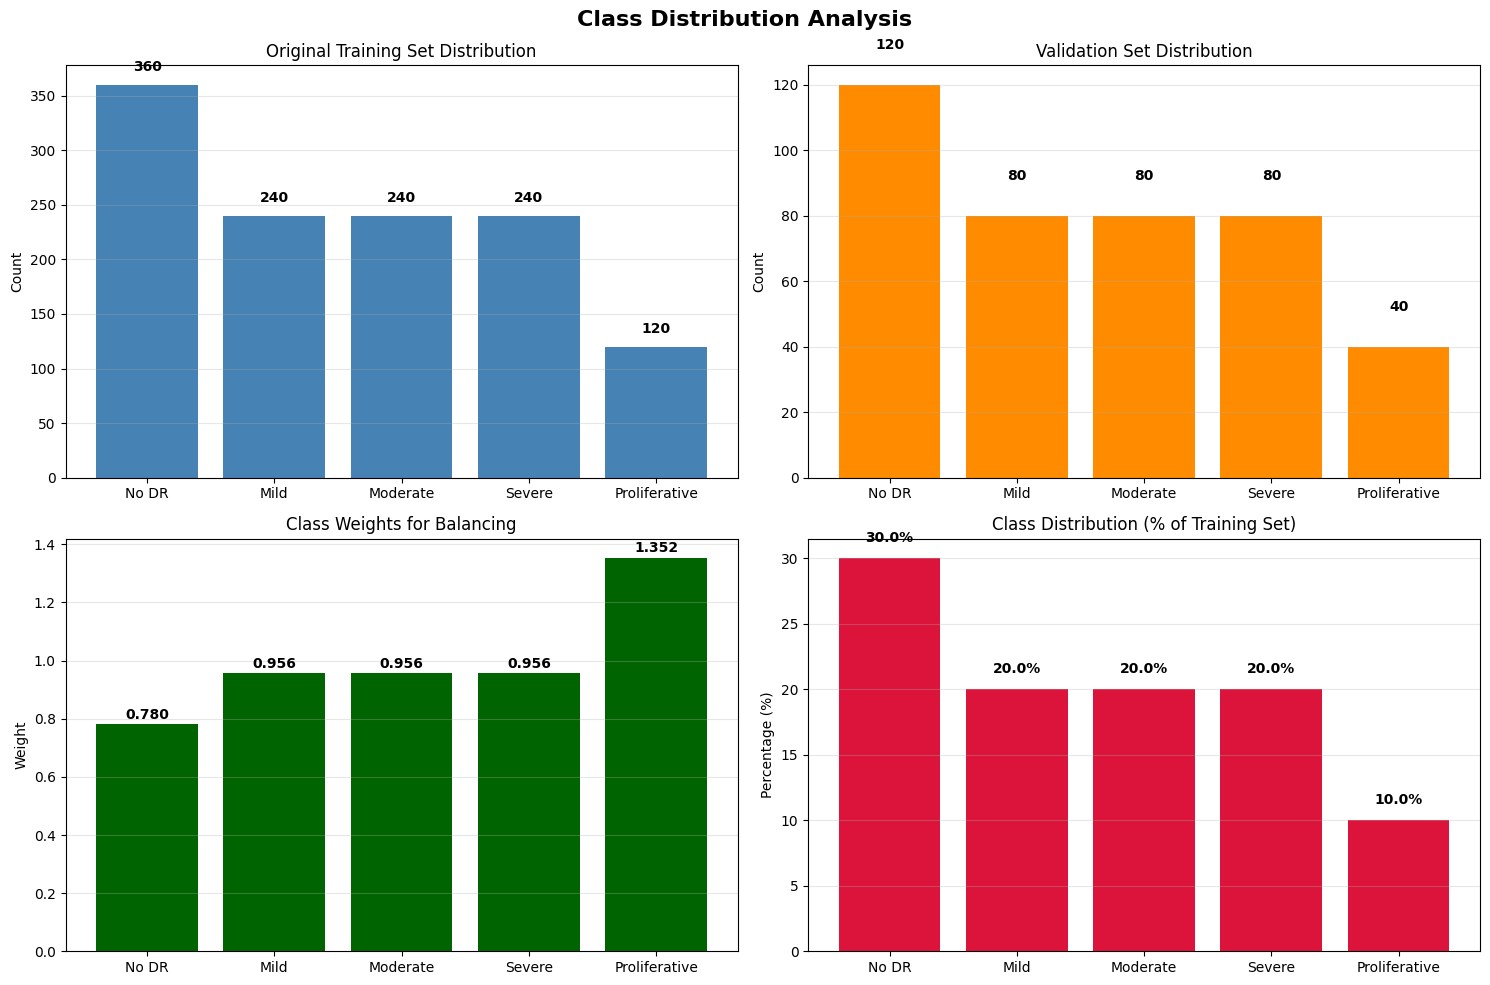


CLASS DISTRIBUTION STATISTICS

Training Set (1200 total):
  No DR          :   360 samples ( 30.0%) | Weight: 0.7805
  Mild           :   240 samples ( 20.0%) | Weight: 0.9559
  Moderate       :   240 samples ( 20.0%) | Weight: 0.9559
  Severe         :   240 samples ( 20.0%) | Weight: 0.9559
  Proliferative  :   120 samples ( 10.0%) | Weight: 1.3518

Validation Set (400 total):
  No DR          :   120 samples ( 30.0%)
  Mild           :    80 samples ( 20.0%)
  Moderate       :    80 samples ( 20.0%)
  Severe         :    80 samples ( 20.0%)
  Proliferative  :    40 samples ( 10.0%)

Test Set (400 total):
  No DR          :   200 samples ( 50.0%)
  Mild           :    36 samples (  9.0%)
  Moderate       :    72 samples ( 18.0%)
  Severe         :    72 samples ( 18.0%)
  Proliferative  :    20 samples (  5.0%)

Imbalance Ratio (max/min): 3.00

✓ Images cached! Training will now load from cache (10x faster).

Loading datasets from cache...
✓ Datasets loaded:
  - Train: 1200 images (

Validation: 100%|██████████| 17/17 [00:03<00:00,  4.38it/s]



Epoch 1/80
Train Loss: 0.7132 | Train Acc: 0.2600 | Train Macro F1: 0.2101
Val Loss: 0.7716 | Val Acc: 0.2925 | Val Macro F1: 0.2322 | ECE: 0.0365
Uncertainty — Vacuity: 0.8309 | Aleatoric: 1.3141 | Epistemic: 0.2788
Best model and checkpoint saved to /content/drive/MyDrive/EyeShield/checkpoints


Validation: 100%|██████████| 17/17 [00:03<00:00,  4.33it/s]



Epoch 2/80
Train Loss: 0.7050 | Train Acc: 0.3675 | Train Macro F1: 0.3071
Val Loss: 0.7386 | Val Acc: 0.3850 | Val Macro F1: 0.3057 | ECE: 0.1000
Uncertainty — Vacuity: 0.7530 | Aleatoric: 1.3179 | Epistemic: 0.2553
Best model and checkpoint saved to /content/drive/MyDrive/EyeShield/checkpoints


...


Epoch 61/80
Train Loss: 0.7153 | Train Acc: 0.7700 | Train Macro F1: 0.7506
Val Loss: 0.8318 | Val Acc: 0.6450 | Val Macro F1: 0.5723 | ECE: 0.1457
Uncertainty — Vacuity: 0.5854 | Aleatoric: 1.1494 | Epistemic: 0.1978


Validation: 100%|██████████| 17/17 [00:03<00:00,  4.37it/s]



Epoch 62/80
Train Loss: 0.7135 | Train Acc: 0.7542 | Train Macro F1: 0.7302
Val Loss: 0.8313 | Val Acc: 0.6600 | Val Macro F1: 0.5933 | ECE: 0.1541
Uncertainty — Vacuity: 0.5766 | Aleatoric: 1.1411 | Epistemic: 0.1948


Validation: 100%|██████████| 17/17 [00:03<00:00,  4.38it/s]



Epoch 63/80
Train Loss: 0.7046 | Train Acc: 0.7742 | Train Macro F1: 0.7541
Val Loss: 0.8302 | Val Acc: 0.6600 | Val Macro F1: 0.6004 | ECE: 0.1589
Uncertainty — Vacuity: 0.5780 | Aleatoric: 1.1481 | Epistemic: 0.1954

Early stopping at epoch 63 (val macro F1 did not improve)

Training Complete!
Training history plot saved to /content/drive/MyDrive/EyeShield/logs


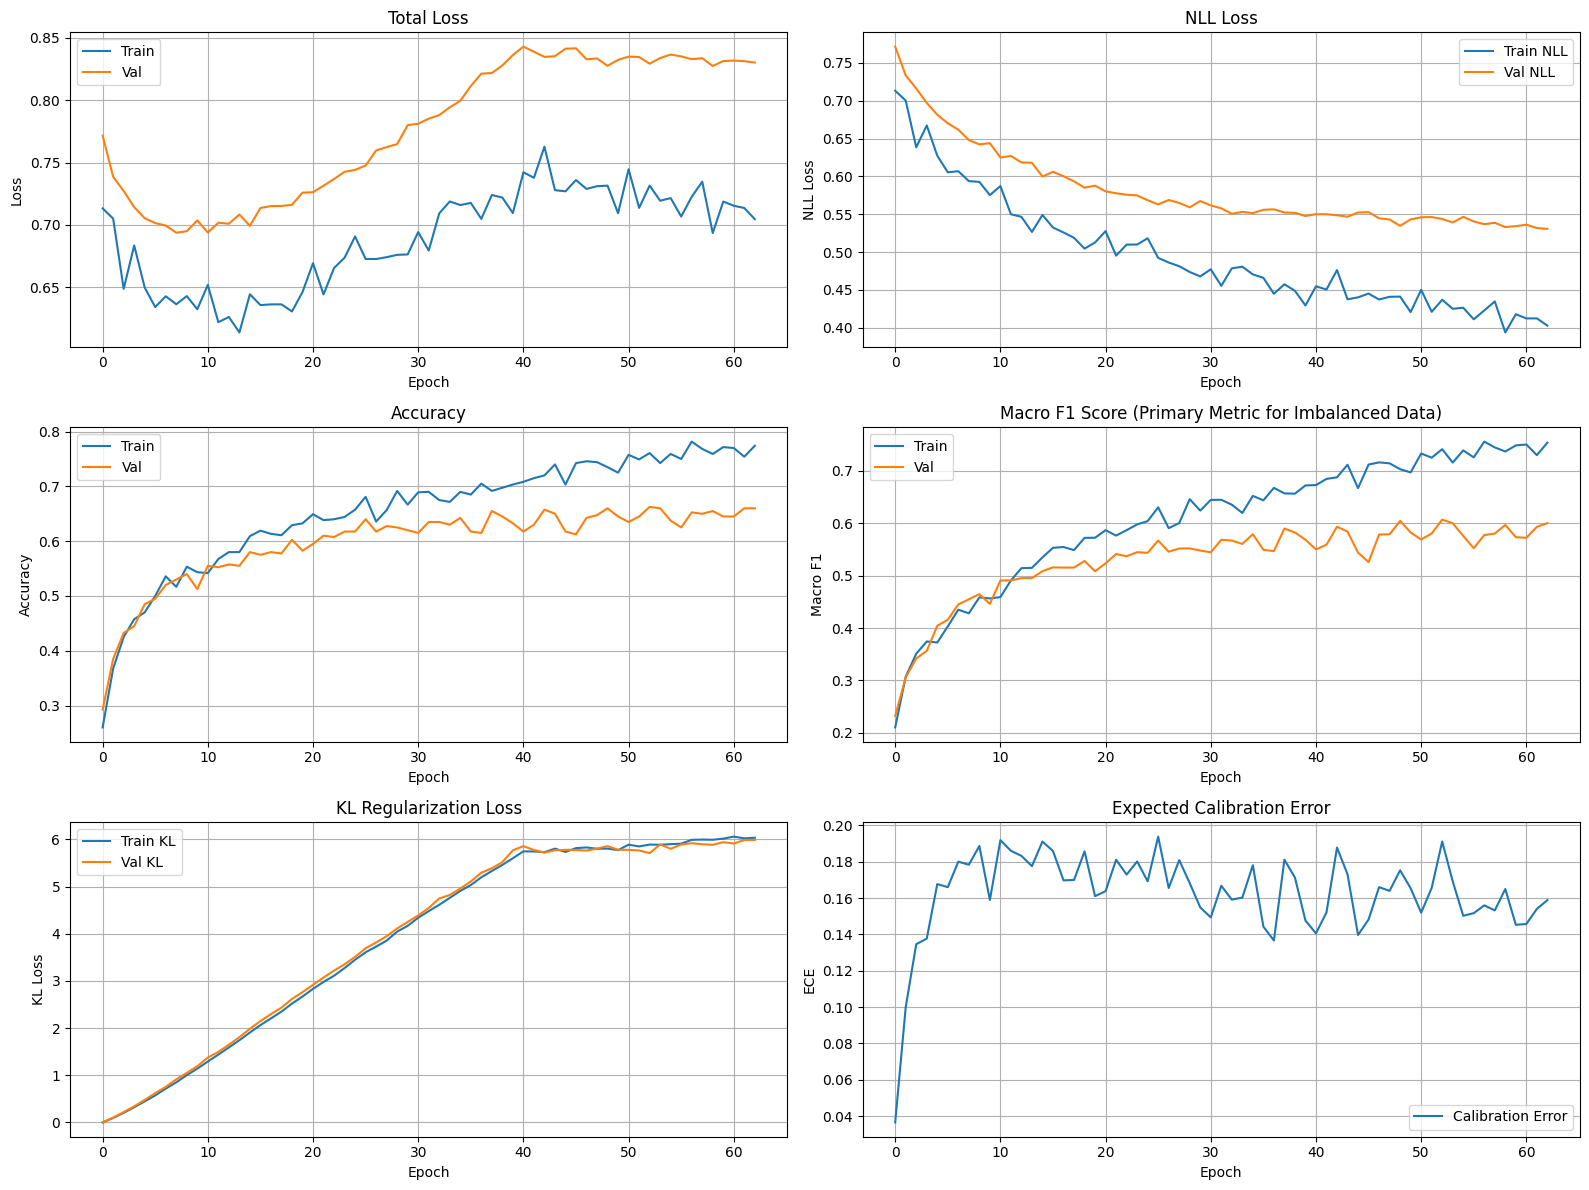


Final model saved to /content/drive/MyDrive/EyeShield/checkpoints/final_model.pth

✓ Training completed!

⏳ Running final backup...
✓ All files backed up to Google Drive


In [22]:
# Validate prerequisites before training
import os

print("="*80)
print("PRE-TRAINING VALIDATION")
print("="*80)

# Check 1: CSV exists and has data
csv_path = '/content/dataset/labels.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"❌ Dataset CSV not found: {csv_path}\n"
                           f"   Please run the 'Prepare Dataset CSV' cell first")

import pandas as pd
df = pd.read_csv(csv_path)
if len(df) == 0:
    raise ValueError(f"❌ Dataset CSV is empty: {csv_path}\n"
                    f"   The CSV was created but contains no images.")

print(f"✓ CSV exists with {len(df)} images")

# Check 2: Training script exists
script_path = '/content/eyeshield_training_preprocessor_deepdrid_modified.py'
if not os.path.exists(script_path):
    raise FileNotFoundError(f"❌ Training script not found: {script_path}\n"
                           f"   Please run the 'Modify Config and Run Training' cell first")
print(f"✓ Training script ready")

# Check 2b: image_processor module exists (required by training script)
image_processor_path = '/content/image_processor.py'
if not os.path.exists(image_processor_path) or os.path.getsize(image_processor_path) == 0:
    print("⚠ image_processor.py not found. Attempting to download...")
    from urllib.request import urlretrieve

    image_processor_url = "https://raw.githubusercontent.com/dondondon22/EyeShield/refs/heads/main/image_processor.py"
    try:
        urlretrieve(image_processor_url, image_processor_path)
    except Exception as e:
        raise FileNotFoundError(
            f"❌ Required module missing: {image_processor_path}\n"
            f"   Auto-download failed: {e}\n"
            f"   Please rerun the 'Copy Training Script' cell."
        )

if not os.path.exists(image_processor_path) or os.path.getsize(image_processor_path) == 0:
    raise FileNotFoundError(
        f"❌ Required module is still missing or empty: {image_processor_path}\n"
        f"   Please rerun the 'Copy Training Script' cell."
    )

print("✓ image_processor module ready")

# Check 3: Backup function exists
try:
    backup_all_files  # Test if function is defined
    print("✓ Backup function available")
except NameError:
    raise NameError("❌ Backup function not defined. Please run 'Backup' cell first")

print("="*80)
print("✓ All prerequisites satisfied. Starting training...\n")

# Execute the full training pipeline
%cd /content

import sys
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

# Compatibility patch for older image_processor.py versions downloaded from GitHub
import importlib.util
import numpy as np

def patch_image_processor_module(module_path='/content/image_processor.py'):
    """Patch ImageCacheManager methods at runtime for backward compatibility."""
    if not os.path.exists(module_path):
        raise FileNotFoundError(f"image_processor.py not found at {module_path}")

    spec = importlib.util.spec_from_file_location('image_processor', module_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    def _safe_get_cache_path(self, image_filename):
        safe_filename = str(image_filename).replace('/', '__').replace('\\', '__')
        return os.path.join(self.cache_dir, f"{safe_filename}.npy")

    def _legacy_get_cache_path(self, image_filename):
        return os.path.join(self.cache_dir, f"{image_filename}.npy")

    def _cache_exists(self, image_filename):
        return os.path.exists(_safe_get_cache_path(self, image_filename)) or os.path.exists(
            _legacy_get_cache_path(self, image_filename)
        )

    def _load_cached_image(self, image_filename):
        new_path = _safe_get_cache_path(self, image_filename)
        legacy_path = _legacy_get_cache_path(self, image_filename)

        if os.path.exists(new_path):
            img = np.load(new_path)
        elif os.path.exists(legacy_path):
            img = np.load(legacy_path)
        else:
            raise FileNotFoundError(
                f"Cached image not found in either format:\n"
                f"  - New: {new_path}\n"
                f"  - Legacy: {legacy_path}"
            )

        if img.dtype == np.uint8:
            return img.astype(np.float32) / 255.0
        return img.astype(np.float32)

    def _get_cache_size_gb(self):
        total_size = 0
        if os.path.exists(self.cache_dir):
            for root, _, files in os.walk(self.cache_dir):
                for file in files:
                    if file.endswith('.npy'):
                        file_path = os.path.join(root, file)
                        if os.path.isfile(file_path):
                            total_size += os.path.getsize(file_path)
        return total_size / (1024**3)

    # Patch class methods (safe even if already present)
    module.ImageCacheManager.get_cache_path = _safe_get_cache_path
    module.ImageCacheManager._get_legacy_cache_path = _legacy_get_cache_path
    module.ImageCacheManager.cache_exists = _cache_exists
    module.ImageCacheManager.load_cached_image = _load_cached_image
    module.ImageCacheManager._get_cache_size_gb = _get_cache_size_gb

    # Ensure training script import uses this patched module
    sys.modules['image_processor'] = module

patch_image_processor_module(image_processor_path)
print("✓ image_processor compatibility patch applied")

# Import all training components
print("Loading training script...")
try:
    # Read the modified training script
    with open('/content/eyeshield_training_preprocessor_deepdrid_modified.py', 'r') as f:
        training_script = f.read()

    # Create a namespace with all required modules
    import torch
    import numpy as np
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn
    from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.model_selection import train_test_split
    import cv2
    from PIL import Image
    import pydicom
    from torch.utils.data import WeightedRandomSampler
    import kagglehub

    exec_namespace = {
        '__name__': '__main__',
        '__file__': '/content/eyeshield_training_preprocessor_deepdrid_modified.py',
        'torch': torch,
        'np': np,
        'plt': plt,
        'pd': pd,
        'cv2': cv2,
        'Image': Image,
        'pydicom': pydicom,
        'WeightedRandomSampler': WeightedRandomSampler,
        'train_test_split': train_test_split,
        'confusion_matrix': confusion_matrix,
        'classification_report': classification_report,
        'accuracy_score': accuracy_score,
        'f1_score': f1_score,
        'StandardScaler': StandardScaler,
        'kagglehub': kagglehub,
    }

    # Execute the script
    exec(training_script, exec_namespace)

    print("\n✓ Training completed!")

except FileNotFoundError as e:
    print(f"❌ File not found: {e}")
except Exception as e:
    print(f"❌ Error: {type(e).__name__}: {str(e)}")
    import traceback
    print("\nFull traceback:")
    traceback.print_exc()

finally:
    # Always backup on training completion or error
    print("\n⏳ Running final backup...")
    backup_all_files()
    print("✓ All files backed up to Google Drive")

# Evaluation and Testing

In [23]:
# Load Model Definition and Classes for Evaluation (Safe - No Training)
import sys
import torch
import re

sys.path.insert(0, '/content')

# Import the training module to get model class and config
print("Loading model class from training script...")
print("⚠ Extracting only class definitions (no training will execute)")

try:
    # Read the training script
    with open('/content/eyeshield_training_preprocessor_deepdrid_modified.py', 'r') as f:
        training_code = f.read()

    # Find and extract only the class definitions
    # Extract everything before "if __name__" or "trainer = Trainer" to avoid running training
    cutoff_markers = ['if __name__', 'trainer = Trainer', '# Train the model', 'trainer.train()']
    cutoff_index = len(training_code)

    for marker in cutoff_markers:
        idx = training_code.find(marker)
        if idx != -1 and idx < cutoff_index:
            cutoff_index = idx

    # Keep only the definitions part
    definitions_only = training_code[:cutoff_index]

    # Create a safe namespace for execution (only classes/functions, no side effects)
    model_namespace = {
        '__name__': '__main__',
        'torch': torch,
        'nn': torch.nn,
        'np': __import__('numpy'),
        'pd': __import__('pandas'),
        'cv2': __import__('cv2'),
        'pydicom': __import__('pydicom'),
        'Image': __import__('PIL').Image,
        'transforms': __import__('torchvision.transforms', fromlist=['transforms']),
        'models': __import__('torchvision.models', fromlist=['models']),
    }

    # Execute only the class definitions (not the training code)
    exec(definitions_only, model_namespace)

    # Extract the model class and config
    EfficientNetB3EDL = model_namespace.get('EfficientNetB3EDL')
    Config = model_namespace.get('Config')

    if EfficientNetB3EDL:
        print("✓ EfficientNetB3EDL class loaded successfully")
    else:
        print("⚠ EfficientNetB3EDL class not found")

    if Config:
        print("✓ Config class loaded successfully")
    else:
        print("⚠ Config class not found")

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"✓ Using device: {device}")
    print("\n✓ Ready for evaluation - NO TRAINING EXECUTED")

except Exception as e:
    print(f"❌ Error loading model class: {e}")
    import traceback
    traceback.print_exc()



Loading model class from training script...
⚠ Extracting only class definitions (no training will execute)
Device: cuda
CUDA Available: True
GPU: NVIDIA L4
✓ EfficientNetB3EDL class loaded successfully
✓ Config class loaded successfully
✓ Using device: cuda

✓ Ready for evaluation - NO TRAINING EXECUTED


In [24]:
# Create Test DataLoader for Evaluation
# Reads the 'test' split written by Cell 11 (DeepDRiD Evaluation / Set-C).
import os
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import cv2
import numpy as np
from PIL import Image
from torchvision import transforms

print("=" * 80)
print("CREATING TEST DATALOADER (DeepDRiD Set-C / Evaluation)")
print("=" * 80)

try:
    csv_path = '/content/dataset/labels.csv'
    df_full  = pd.read_csv(csv_path)
    print(f"\n✓ Loaded labels.csv — {len(df_full)} total rows")
    print(f"  Split counts:\n{df_full['split'].value_counts().to_string()}")

    # ── Use the official 'test' split (DeepDRiD Set-C evaluation set) ────────
    if 'split' not in df_full.columns or (df_full['split'] == 'test').sum() == 0:
        raise RuntimeError(
            "No 'test' rows found in labels.csv.\n"
            "Re-run 'Prepare Dataset CSV' (Cell 11) so the Evaluation folder "
            "is included as split=test."
        )

    test_df = df_full[df_full['split'] == 'test'].reset_index(drop=True)
    print(f"\n✓ Test set (Set-C): {len(test_df)} images")
    print(f"  Class distribution:\n{test_df['diagnosis'].value_counts().sort_index().to_string()}")

    # ── Validate that image files exist on disk ───────────────────────────────
    # Cell 11 stores absolute paths, so no root-joining needed.
    exists_mask = test_df['image_path'].apply(os.path.exists)
    missing     = int((~exists_mask).sum())
    if missing:
        print(f"\n⚠ {missing} images not found on disk — dropping them")
    test_df = test_df[exists_mask].reset_index(drop=True)
    test_df['full_path'] = test_df['image_path']

    if len(test_df) == 0:
        raise RuntimeError(
            "No valid test images found after path validation.\n"
            "The Evaluation Set-C images may not be present in this Kaggle mirror, "
            "or Challenge1_labels.xlsx was missing — check Cell 11 output."
        )

    print(f"\n✓ Valid test images: {len(test_df)}")

    # ── Dataset ───────────────────────────────────────────────────────────────
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    class FundusImageDataset(Dataset):
        """Loads DeepDRiD images directly from disk (no cache needed for eval)."""

        def __init__(self, eval_df, transform=None):
            self.df        = eval_df
            self.transform = transform

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            row       = self.df.iloc[idx]
            img_path  = row['full_path']
            label     = int(row['diagnosis'])

            img = cv2.imread(img_path)
            if img is None:
                raise FileNotFoundError(f"Failed to read image: {img_path}")

            # Match training preprocessing: resize to 512×512, normalize to [0,1]
            img = cv2.resize(img, (512, 512), interpolation=cv2.INTER_LANCZOS4)
            img = img.astype(np.float32) / 255.0

            pil = Image.fromarray((img * 255).astype(np.uint8))
            img_tensor = self.transform(pil) if self.transform is not None else \
                         torch.from_numpy(img).permute(2, 0, 1)

            return img_tensor, torch.tensor(label, dtype=torch.long)

    test_dataset = FundusImageDataset(test_df, transform=test_transform)

    pin_memory  = torch.cuda.is_available()
    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2,
        pin_memory=pin_memory,
    )

    sample_x, sample_y = test_dataset[0]
    EVAL_VALID_TEST_SIZE = len(test_df)

    print("\n✓ Test DataLoader ready")
    print(f"  Batches      : {len(test_loader)}")
    print(f"  Batch size   : 32")
    print(f"  Total samples: {EVAL_VALID_TEST_SIZE}")
    print(f"  Tensor shape : {tuple(sample_x.shape)}")
    print(f"  Sample label : {int(sample_y)}")
    print("\n✓ Ready for evaluation — run the next cell")

except Exception as e:
    print(f"❌ Error creating test loader: {e}")
    import traceback
    traceback.print_exc()


CREATING TEST DATALOADER (DeepDRiD Set-C / Evaluation)

✓ Loaded labels.csv — 2000 total rows
  Split counts:
split
train    1200
val       400
test      400

✓ Test set (Set-C): 400 images
  Class distribution:
diagnosis
0    200
1     36
2     72
3     72
4     20

✓ Valid test images: 400

✓ Test DataLoader ready
  Batches      : 13
  Batch size   : 32
  Total samples: 400
  Tensor shape : (3, 512, 512)
  Sample label : 1

✓ Ready for evaluation — run the next cell


In [25]:
import os
import re
import glob
from datetime import datetime
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=" * 80)
print("MODEL EVALUATION AND TESTING")
print("=" * 80)
print("NOTE: This cell is manual. If training was interrupted (e.g., during plot_training_history), run this cell explicitly.")
print(f"Evaluation run started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
class_ids = [0, 1, 2, 3, 4]


def parse_f1_from_filename(path):
    """Parse F1 from checkpoint filename like checkpoint_epoch_50_f1_0.5703.pt."""
    m = re.search(r"_f1_([0-9]*\.?[0-9]+)\.pt$", os.path.basename(path))
    return float(m.group(1)) if m else -1.0


def choose_best_checkpoint(checkpoint_dir):
    """Choose checkpoint with highest available validation macro-F1."""
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    named_ckpts = glob.glob(os.path.join(checkpoint_dir, 'checkpoint_epoch_*_f1_*.pt'))

    candidate_paths = []
    if os.path.exists(best_model_path):
        candidate_paths.append(best_model_path)
    candidate_paths.extend(named_ckpts)

    if not candidate_paths:
        raise FileNotFoundError(f"No checkpoint files found in {checkpoint_dir}")

    best_path = None
    best_score = -1.0

    print("\nCheckpoint candidates:")
    for path in candidate_paths:
        score = parse_f1_from_filename(path)
        src = 'filename'

        # Try metadata score when available (more reliable than filename)
        try:
            ckpt = torch.load(path, map_location='cpu', weights_only=False)
            if 'val_metrics' in ckpt and isinstance(ckpt['val_metrics'], dict) and 'macro_f1' in ckpt['val_metrics']:
                score = float(ckpt['val_metrics']['macro_f1'])
                src = 'metadata'
        except Exception:
            pass

        print(f"  - {os.path.basename(path)} -> macro_f1={score:.4f} ({src})")

        if score > best_score:
            best_score = score
            best_path = path

    return best_path, best_score


# Verify prerequisites
if 'EfficientNetB3EDL' not in locals():
    print("⚠ Model class not loaded. Run 'Load Model Definition and Classes for Evaluation' first")
elif 'test_loader' not in locals():
    print("⚠ test_loader not found. Run 'Create Test DataLoader for Evaluation' first")
else:
    try:
        if 'EVAL_TEST_SPLIT_SIZE' in globals() and 'EVAL_VALID_TEST_SIZE' in globals():
            print(f"\n✓ Evaluation split metadata: target_test={EVAL_TEST_SPLIT_SIZE}, valid_test={EVAL_VALID_TEST_SIZE}")
        else:
            print("\n⚠ Split metadata not found. Re-run the previous DataLoader cell to ensure correct test split.")

        checkpoint_dir = '/content/drive/MyDrive/EyeShield/checkpoints'
        checkpoint_path, selected_score = choose_best_checkpoint(checkpoint_dir)

        print("\n✓ Loading selected checkpoint...")
        checkpoint = torch.load(checkpoint_path, weights_only=False)

        model = EfficientNetB3EDL(num_classes=5, pretrained=False)
        model.load_state_dict(checkpoint['model_state'])
        model.to(device)
        model.eval()

        print("✓ Model loaded successfully")
        print(f"  - Checkpoint path: {checkpoint_path}")
        print(f"  - Selected macro F1 score: {selected_score:.4f}")
        print(f"  - Checkpoint epoch: {checkpoint.get('epoch', 'unknown')}")
        print(f"  - Model parameters: {sum(p.numel() for p in model.parameters()):,}")
        if 'val_metrics' in checkpoint and isinstance(checkpoint['val_metrics'], dict):
            vm = checkpoint['val_metrics']
            if 'macro_f1' in vm:
                print(f"  - Checkpoint val macro F1: {vm['macro_f1']:.4f}")
            if 'accuracy' in vm:
                print(f"  - Checkpoint val accuracy: {vm['accuracy']:.4f}")

        print("\nRunning evaluation on test set...")
        all_preds = []
        all_targets = []
        all_uncertainties = []

        with torch.no_grad():
            for images, targets in test_loader:
                images = images.to(device, non_blocking=True)
                targets = targets.to(device, non_blocking=True)

                evidence = model(images)
                output = model.predict(evidence)

                all_preds.extend(output['pred'].cpu().numpy().tolist())
                all_targets.extend(targets.cpu().numpy().tolist())
                all_uncertainties.extend(output['uncertainty'].cpu().numpy().reshape(-1).tolist())

        all_preds = np.array(all_preds, dtype=np.int64)
        all_targets = np.array(all_targets, dtype=np.int64)
        all_uncertainties = np.array(all_uncertainties, dtype=np.float32)

        print(f"✓ Evaluated samples: {len(all_targets)}")

        # Distribution diagnostics
        true_counts = np.bincount(all_targets, minlength=5)
        pred_counts = np.bincount(all_preds, minlength=5)

        print("\nClass distribution (true vs predicted):")
        for cid, cname in enumerate(class_names):
            print(f"  {cname:<13} true={true_counts[cid]:5d}  pred={pred_counts[cid]:5d}")

        unique_pred = np.unique(all_preds)
        if len(unique_pred) == 1:
            print(f"\n⚠ Prediction collapse detected: model predicted only class {int(unique_pred[0])} ({class_names[int(unique_pred[0])]})")
            print("  This usually indicates dataset/path/preprocessing mismatch during evaluation.")

        # Confusion matrix with fixed class axes
        cm = confusion_matrix(all_targets, all_preds, labels=class_ids)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax,
            xticklabels=class_names,
            yticklabels=class_names,
        )
        ax.set_title('Confusion Matrix - DR Classification')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/EyeShield/logs/confusion_matrix.png', dpi=300)
        plt.show()

        # Classification report with fixed labels
        print("\nClassification Report:")
        print(
            classification_report(
                all_targets,
                all_preds,
                labels=class_ids,
                target_names=class_names,
                digits=4,
                zero_division=0,
            )
        )

        # Uncertainty plots (downsample if very large to keep plotting responsive)
        max_points = 20000
        if len(all_uncertainties) > max_points:
            rng = np.random.default_rng(42)
            idx = rng.choice(len(all_uncertainties), size=max_points, replace=False)
            unc_plot = all_uncertainties[idx]
            preds_plot = all_preds[idx]
            targets_plot = all_targets[idx]
            print(f"\n⚠ Downsampled uncertainty plots to {max_points} points for responsiveness")
        else:
            unc_plot = all_uncertainties
            preds_plot = all_preds
            targets_plot = all_targets

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].hist(unc_plot, bins=40, alpha=0.7)
        axes[0].set_title('Uncertainty Distribution')
        axes[0].set_xlabel('Uncertainty')
        axes[0].set_ylabel('Frequency')

        correct_mask = preds_plot == targets_plot
        correct_unc = unc_plot[correct_mask]
        incorrect_unc = unc_plot[~correct_mask]

        axes[1].hist(correct_unc, bins=25, alpha=0.7, label='Correct')
        axes[1].hist(incorrect_unc, bins=25, alpha=0.7, label='Incorrect')
        axes[1].set_title('Uncertainty: Correct vs Incorrect')
        axes[1].set_xlabel('Uncertainty')
        axes[1].set_ylabel('Frequency')
        axes[1].legend()

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/EyeShield/logs/uncertainty_analysis.png', dpi=300)
        plt.show()

        EVALUATION_LAST_RUN_AT = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        print(f"\n✓ Evaluation complete at {EVALUATION_LAST_RUN_AT}")

    except FileNotFoundError as e:
        print(f"❌ File not found: {e}")
        print('   Make sure checkpoints have been saved during training')
    except Exception as e:
        print(f"❌ Error: {type(e).__name__}: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "=" * 80)

MODEL EVALUATION AND TESTING
NOTE: This cell is manual. If training was interrupted (e.g., during plot_training_history), run this cell explicitly.
Evaluation run started at: 2026-04-08 07:36:14

⚠ Split metadata not found. Re-run the previous DataLoader cell to ensure correct test split.

Checkpoint candidates:
  - best_model.pth -> macro_f1=-1.0000 (filename)

✓ Loading selected checkpoint...
❌ Error: AttributeError: 'NoneType' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 879, in _check_seekable
    f.seek(f.tell())
    ^^^^^^
AttributeError: 'NoneType' object has no attribute 'seek'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/tmp/ipykernel_12775/1800476782.py", line 82, in <cell line: 0>
    checkpoint = torch.load(checkpoint_path, weights_only=False)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1500, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 773, in _open_file_like
    return _open_buffer_reader(name_or_buffer)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 758, in __init__

# Temperature Scaling and Uncertainty Rejection

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch.optim import LBFGS
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

print("="*60)
print("POST-TRAINING CALIBRATION + REJECTION PIPELINE")
print("="*60)

# Ensure required runtime objects exist
if 'model' not in globals() or model is None:
    raise NameError(
        "model is not defined. Run the model evaluation loading cell first "
        "(the one that loads checkpoint into `model`)."
    )

if 'device' not in globals() or device is None:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Resolve calibration loader
if 'val_loader' in globals() and val_loader is not None:
    calibration_loader = val_loader
    print("✓ Using val_loader for calibration")
elif 'test_loader' in globals() and test_loader is not None:
    calibration_loader = test_loader
    val_loader = test_loader  # Backward compatibility for downstream code
    print("⚠ val_loader not found; using test_loader for calibration")
else:
    raise NameError(
        "Neither val_loader nor test_loader is defined. "
        "Run the 'Create Test DataLoader for Evaluation' cell first."
    )

if len(calibration_loader) == 0:
    raise RuntimeError("Calibration loader is empty. Recreate the evaluation DataLoader.")


# ── TEMPERATURE SCALING CLASS ─────────────────────────────────
class TemperatureScaler(nn.Module):
    """Wraps trained EDL model with learnable temperature parameter."""

    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        evidence = self.model(x)
        return evidence / self.temperature

    def predict(self, evidence):
        return self.model.predict(evidence)


# ── STEP 1: COLLECT VAL EVIDENCE ─────────────────────────────
print("\nStep 1: Collecting validation evidence...")
model.eval()

all_evidence, all_labels = [], []

with torch.no_grad():
    for images, labels in calibration_loader:
        images = images.to(device)
        evidence = model(images)
        all_evidence.append(evidence.cpu())
        all_labels.append(labels)

all_evidence = torch.cat(all_evidence).to(device)
all_labels   = torch.cat(all_labels).to(device)
print(f"✓ Collected {len(all_labels)} calibration samples")


# ── STEP 2: FIND OPTIMAL TEMPERATURE ─────────────────────────
print("\nStep 2: Optimizing temperature...")

temperature = nn.Parameter(torch.ones(1).to(device) * 1.5)
optimizer   = LBFGS([temperature], lr=0.01, max_iter=200)
criterion   = nn.CrossEntropyLoss()

def eval_step():
    optimizer.zero_grad()
    scaled_evidence = all_evidence / temperature
    alpha   = scaled_evidence + 1
    S       = alpha.sum(dim=1, keepdim=True)
    belief  = alpha / S
    loss    = criterion(belief, all_labels)
    loss.backward()
    return loss

optimizer.step(eval_step)

optimal_T = temperature.item()
print(f"✓ Optimal temperature: T = {optimal_T:.4f}")

if optimal_T > 2.0:
    print("  → Model was very overconfident — temperature softened beliefs significantly")
elif optimal_T > 1.0:
    print("  → Model was mildly overconfident — beliefs slightly softened")
else:
    print("  → Model was underconfident — beliefs sharpened")


# ── STEP 3: WRAP MODEL WITH TEMPERATURE ──────────────────────
print("\nStep 3: Wrapping model with optimal temperature...")
calibrated_model = TemperatureScaler(model)
calibrated_model.temperature = nn.Parameter(
    torch.tensor([optimal_T])
)
calibrated_model = calibrated_model.to(device)
calibrated_model.eval()

# Save calibrated model
torch.save({
    'model_state':  model.state_dict(),
    'temperature':  optimal_T,
    'base_f1':      float(checkpoint.get('val_metrics', {}).get('macro_f1', -1)),
    'base_epoch':   int(checkpoint.get('epoch', -1))
}, '/content/drive/MyDrive/EyeShield/checkpoints/calibrated_model.pt')
print("✓ Calibrated model saved")


# ── STEP 4: COMPARE BEFORE vs AFTER ──────────────────────────
print("\nStep 4: Comparing ECE before vs after calibration...")

def compute_ece_and_metrics(mdl, loader, device, label):
    mdl.eval()
    all_preds, all_targets = [], []
    all_uncertainties, all_beliefs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            evidence = mdl(images)
            output   = mdl.predict(evidence)

            all_preds.extend(output['pred'].cpu().numpy())
            all_targets.extend(labels.numpy())
            all_uncertainties.extend(
                output['uncertainty'].view(-1).cpu().numpy()
            )
            all_beliefs.extend(output['belief'].cpu().numpy())

    preds        = np.array(all_preds)
    targets      = np.array(all_targets)
    uncertainties = np.array(all_uncertainties)
    beliefs      = np.array(all_beliefs)
    confidences  = beliefs.max(axis=1)

    # ECE
    n_bins = 10
    bins   = np.linspace(0, 1, n_bins + 1)
    ece    = 0.0
    for i in range(n_bins):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if mask.sum() > 0:
            ece += (np.abs(confidences[mask].mean() -
                           (preds[mask] == targets[mask]).mean()) *
                    mask.sum() / len(targets))

    acc = accuracy_score(targets, preds)
    f1  = f1_score(targets, preds, average='macro', zero_division=0)

    print(f"\n  {label}:")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    Macro F1  : {f1:.4f}")
    print(f"    ECE       : {ece:.4f}")
    print(f"    Unc range : {uncertainties.min():.3f} – "
          f"{uncertainties.max():.3f}")
    print(f"    Unc mean  : {uncertainties.mean():.4f}")

    return preds, targets, uncertainties, beliefs

# Before calibration
preds_raw, targets, unc_raw, beliefs_raw = compute_ece_and_metrics(
    model, calibration_loader, device, 'Before Calibration'
)
# After calibration
preds_cal, _,       unc_cal, beliefs_cal = compute_ece_and_metrics(
    calibrated_model, calibration_loader, device, 'After Calibration'
)


# ── STEP 5: FIND OPTIMAL REJECTION THRESHOLD ─────────────────
print("\n" + "="*60)
print("Step 5: Finding optimal rejection threshold...")
print("="*60)

thresholds = np.arange(0.10, 1.01, 0.05)

print(f"\n{'Threshold':<12} {'Accept%':<10} {'Reject%':<10} "
      f"{'Accuracy':<12} {'Macro F1':<12} {'Note'}")
print("-" * 68)

best_t   = None
best_f1  = 0.0
results  = []

for t in thresholds:
    accepted = unc_cal < t
    if accepted.sum() < 10:
        continue

    rej_rate = (~accepted).mean() * 100
    acc = accuracy_score(targets[accepted], preds_cal[accepted])
    f1  = f1_score(targets[accepted], preds_cal[accepted],
                   average='macro', zero_division=0)

    note = ''
    if rej_rate <= 30 and f1 > best_f1:
        best_f1 = f1
        best_t  = t
        note    = '← BEST'

    results.append({
        'threshold':    t,
        'accepted':     accepted.sum(),
        'rejection_rate': rej_rate,
        'accuracy':     acc,
        'macro_f1':     f1
    })

    print(f"{t:<12.2f} {100-rej_rate:<10.1f} {rej_rate:<10.1f} "
          f"{acc:<12.4f} {f1:<12.4f} {note}")

print(f"\n✓ Optimal threshold : {best_t:.2f}")
print(f"  Macro F1 accepted : {best_f1:.4f}")


# ── STEP 6: PLOT EVERYTHING ───────────────────────────────────
print("\nStep 6: Plotting calibration and rejection curves...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Reliability diagram — before
conf_raw = beliefs_raw.max(axis=1)
bins_plot = np.linspace(0, 1, 11)
bin_accs_raw, bin_confs_raw = [], []
for i in range(10):
    mask = (conf_raw >= bins_plot[i]) & (conf_raw < bins_plot[i+1])
    if mask.sum() > 0:
        bin_accs_raw.append((preds_raw[mask] == targets[mask]).mean())
        bin_confs_raw.append(conf_raw[mask].mean())

axes[0,0].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[0,0].bar(bins_plot[:-1], bin_accs_raw, width=0.1,
              align='edge', alpha=0.7, label='Model')
axes[0,0].set_title('Reliability Diagram — Before Calibration')
axes[0,0].set_xlabel('Confidence')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()

# Reliability diagram — after
conf_cal = beliefs_cal.max(axis=1)
bin_accs_cal, bin_confs_cal = [], []
for i in range(10):
    mask = (conf_cal >= bins_plot[i]) & (conf_cal < bins_plot[i+1])
    if mask.sum() > 0:
        bin_accs_cal.append((preds_cal[mask] == targets[mask]).mean())
        bin_confs_cal.append(conf_cal[mask].mean())

axes[0,1].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[0,1].bar(bins_plot[:-1], bin_accs_cal, width=0.1,
              align='edge', alpha=0.7, color='orange', label='Model')
axes[0,1].set_title('Reliability Diagram — After Calibration')
axes[0,1].set_xlabel('Confidence')
axes[0,1].legend()

# Uncertainty distribution — before vs after
axes[0,2].hist(unc_raw, bins=50, alpha=0.6, label='Before', color='blue')
axes[0,2].hist(unc_cal, bins=50, alpha=0.6, label='After',  color='orange')
axes[0,2].set_title('Uncertainty Distribution')
axes[0,2].set_xlabel('Uncertainty')
axes[0,2].legend()

# F1 vs threshold
axes[1,0].plot([r['threshold'] for r in results],
               [r['macro_f1']  for r in results], 'g-o')
axes[1,0].axvline(best_t, color='red', linestyle='--',
                  label=f'Optimal T={best_t:.2f}')
axes[1,0].set_title('Macro F1 vs Rejection Threshold')
axes[1,0].set_xlabel('Uncertainty Threshold')
axes[1,0].set_ylabel('Macro F1 on Accepted')
axes[1,0].legend()
axes[1,0].grid(True)

# Rejection rate vs threshold
axes[1,1].plot([r['threshold']     for r in results],
               [r['rejection_rate'] for r in results], 'r-o')
axes[1,1].axvline(best_t, color='red', linestyle='--',
                  label=f'Optimal T={best_t:.2f}')
axes[1,1].set_title('Rejection Rate vs Threshold')
axes[1,1].set_xlabel('Uncertainty Threshold')
axes[1,1].set_ylabel('% Rejected')
axes[1,1].legend()
axes[1,1].grid(True)

# Correct vs incorrect uncertainty
correct_mask = preds_cal == targets
axes[1,2].hist(unc_cal[correct_mask],  bins=40, alpha=0.7,
               label=f'Correct ({correct_mask.sum()})',   color='green')
axes[1,2].hist(unc_cal[~correct_mask], bins=40, alpha=0.7,
               label=f'Incorrect ({(~correct_mask).sum()})', color='red')
axes[1,2].axvline(best_t, color='black', linestyle='--',
                  label=f'Threshold={best_t:.2f}')
axes[1,2].set_title('Uncertainty: Correct vs Incorrect')
axes[1,2].set_xlabel('Uncertainty')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EyeShield/logs/calibration_rejection.png',
            dpi=300)
plt.show()
print("✓ Plots saved")
print(f"\n{'='*60}")
print(f"FINAL MODEL SUMMARY")
print(f"{'='*60}")
print(f"  Temperature     : {optimal_T:.4f}")
print(f"  Optimal threshold: {best_t:.2f}")
print(f"  Best F1 accepted : {best_f1:.4f}")
print(f"  Calibrated model : calibrated_model.pt")